In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/amritachatterjee09/lead-scoring-dataset/Lead Scoring.csv
/kaggle/input/datasets/amritachatterjee09/lead-scoring-dataset/Leads Data Dictionary.xlsx


In [2]:
data_frame = pd.read_csv("/kaggle/input/datasets/amritachatterjee09/lead-scoring-dataset/Lead Scoring.csv")
data_frame.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [3]:
import random

# 100 English first names
first_names = [
    "James","John","Robert","Michael","William","David","Richard","Joseph","Thomas","Charles",
    "Christopher","Daniel","Matthew","Anthony","Mark","Donald","Steven","Paul","Andrew","Joshua",
    "Kenneth","Kevin","Brian","George","Edward","Ronald","Timothy","Jason","Jeffrey","Ryan",
    "Jacob","Gary","Nicholas","Eric","Jonathan","Stephen","Larry","Justin","Scott","Brandon",
    "Benjamin","Samuel","Gregory","Frank","Alexander","Raymond","Patrick","Jack","Dennis","Jerry",
    "Tyler","Aaron","Jose","Adam","Nathan","Henry","Douglas","Zachary","Peter","Kyle",
    "Walter","Ethan","Jeremy","Harold","Keith","Christian","Roger","Noah","Gerald","Carl",
    "Terry","Sean","Austin","Arthur","Lawrence","Jesse","Dylan","Bryan","Joe","Jordan",
    "Billy","Bruce","Albert","Willie","Gabriel","Logan","Alan","Juan","Wayne","Roy",
    "Ralph","Randy","Eugene","Vincent","Russell","Louis","Philip","Bobby","Johnny","Bradley"
]

# 100 English last names
last_names = [
    "Smith","Johnson","Williams","Brown","Jones","Garcia","Miller","Davis","Rodriguez","Martinez",
    "Hernandez","Lopez","Gonzalez","Wilson","Anderson","Thomas","Taylor","Moore","Jackson","Martin",
    "Lee","Perez","Thompson","White","Harris","Sanchez","Clark","Ramirez","Lewis","Robinson",
    "Walker","Young","Allen","King","Wright","Scott","Torres","Nguyen","Hill","Flores",
    "Green","Adams","Nelson","Baker","Hall","Rivera","Campbell","Mitchell","Carter","Roberts",
    "Gomez","Phillips","Evans","Turner","Diaz","Parker","Cruz","Edwards","Collins","Reyes",
    "Stewart","Morris","Morales","Murphy","Cook","Rogers","Gutierrez","Ortiz","Morgan","Cooper",
    "Peterson","Bailey","Reed","Kelly","Howard","Ramos","Kim","Cox","Ward","Richardson",
    "Watson","Brooks","Chavez","Wood","James","Bennett","Gray","Mendoza","Ruiz","Hughes",
    "Price","Alvarez","Castillo","Sanders","Patel","Myers","Long","Ross","Foster","Jimenez"
]

# Create all unique combinations
all_names = [f"{f} {l}" for f in first_names for l in last_names]

# Shuffle names randomly
random.shuffle(all_names)

# Assign first 9240 unique names to dataframe
data_frame['Full Name'] = all_names[:len(data_frame)]

# Remove Full Name column temporarily
full_name_col = data_frame.pop('Full Name')

# Insert it at position 1 (2nd column)
data_frame.insert(1, 'Full Name', full_name_col)

# Preview
data_frame.head()


,Prospect ID,Full Name,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,Brandon Allen,660737,API,Olark Chat,No,No,0,0.0,0,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,Kenneth Baker,660728,API,Organic Search,No,No,0,5.0,674,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,Steven Torres,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,Ethan Ruiz,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,...,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,Brandon Morris,660681,Landing Page Submission,Google,No,No,1,2.0,1428,...,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


# Initial Data Exploration

In [4]:
data_frame.columns

Index(['Prospect ID', 'Full Name', 'Lead Number', 'Lead Origin', 'Lead Source',
       'Do Not Email', 'Do Not Call', 'Converted', 'TotalVisits',
       'Total Time Spent on Website', 'Page Views Per Visit', 'Last Activity',
       'Country', 'Specialization', 'How did you hear about X Education',
       'What is your current occupation',
       'What matters most to you in choosing a course', 'Search', 'Magazine',
       'Newspaper Article', 'X Education Forums', 'Newspaper',
       'Digital Advertisement', 'Through Recommendations',
       'Receive More Updates About Our Courses', 'Tags', 'Lead Quality',
       'Update me on Supply Chain Content', 'Get updates on DM Content',
       'Lead Profile', 'City', 'Asymmetrique Activity Index',
       'Asymmetrique Profile Index', 'Asymmetrique Activity Score',
       'Asymmetrique Profile Score',
       'I agree to pay the amount through cheque',
       'A free copy of Mastering The Interview', 'Last Notable Activity'],
      dtype='object'

In [5]:
data_frame.shape

(9240, 38)

In [6]:
data_frame.describe()

,Lead Number,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Asymmetrique Activity Score,Asymmetrique Profile Score
count,9240.000000,9240.000000,9103.000000,9240.000000,9103.000000,5022.000000,5022.000000
mean,617188.435606,0.385390,3.445238,487.698268,2.362820,14.306252,16.344883
std,23405.995698,0.486714,4.854853,548.021466,2.161418,1.386694,1.811395
min,579533.000000,0.000000,0.000000,0.000000,0.000000,7.000000,11.000000
25%,596484.500000,0.000000,1.000000,12.000000,1.000000,14.000000,15.000000
50%,615479.000000,0.000000,3.000000,248.000000,2.000000,14.000000,16.000000
75%,637387.250000,1.000000,5.000000,936.000000,3.000000,15.000000,18.000000
max,660737.000000,1.000000,251.000000,2272.000000,55.000000,18.000000,20.000000


# Findings from Descriptive Statistics

1. Average website engagement per lead is moderate.
2. Only 38.5% of leads converted successfully.
3. Leads with higher website visits and time spent may indicate stronger buying intent.
4. Some variables contain missing values requiring preprocessing.
5. Significant variation exists among customer engagement behavior.


In [7]:
data_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 38 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Full Name                                      9240 non-null   object 
 2   Lead Number                                    9240 non-null   int64  
 3   Lead Origin                                    9240 non-null   object 
 4   Lead Source                                    9204 non-null   object 
 5   Do Not Email                                   9240 non-null   object 
 6   Do Not Call                                    9240 non-null   object 
 7   Converted                                      9240 non-null   int64  
 8   TotalVisits                                    9103 non-null   float64
 9   Total Time Spent on Website                    9240 

In [8]:
data_frame.isnull().sum()

Prospect ID                                         0
Full Name                                           0
Lead Number                                         0
Lead Origin                                         0
Lead Source                                        36
Do Not Email                                        0
Do Not Call                                         0
Converted                                           0
TotalVisits                                       137
Total Time Spent on Website                         0
Page Views Per Visit                              137
Last Activity                                     103
Country                                          2461
Specialization                                   1438
How did you hear about X Education               2207
What is your current occupation                  2690
What matters most to you in choosing a course    2709
Search                                              0
Magazine                    

# Cleaning and handling missing data

> Variables containing a high percentage of missing values were removed from the dataset to improve data quality and reduce analytical inconsistencies. Columns with limited business relevance and excessive null values were excluded from further analysis.

In [9]:
columns_to_drop = [
    'Asymmetrique Activity Index',
    'Asymmetrique Profile Index',
    'Asymmetrique Activity Score',
    'Asymmetrique Profile Score',
    'Lead Quality',
    'Tags',
    'Magazine',
    'Receive More Updates About Our Courses',
    'Update me on Supply Chain Content',
    'Get updates on DM Content',
    'I agree to pay the amount through cheque'
]

data_frame.drop(columns=columns_to_drop, inplace=True, errors='ignore')

**Missing numerical values were replaced using the median imputation method to reduce the impact of outliers and maintain data consistency.**

Some customers may visit:

* 1 time
* 3 times
* 250 times

This creates outliers.
Mean becomes distorted.

Median is safer because:

1. it represents the middle value
2. less affected by extreme values


In [10]:
data_frame['TotalVisits'] = data_frame['TotalVisits'].fillna(
    data_frame['TotalVisits'].median()
)

data_frame['Page Views Per Visit'] = data_frame['Page Views Per Visit'].fillna(
    data_frame['Page Views Per Visit'].median()
)

# Feature Selection - By removing unwanted columns

In [11]:
#REMOVE USELESS COLUMNS
#These columns are identifiers only.
drop_cols = [
    'Prospect ID',
    'Full Name'
    'Lead Number'
]

data_frame.drop(columns=drop_cols, inplace=True, errors='ignore')

In [12]:
#REMOVE VERY LOW VARIANCE COLUMNS
#These columns mostly contain same value everywhere.
low_variance_cols = [
    'Do Not Call',
    'Search',
    'Newspaper Article',
    'X Education Forums',
    'Newspaper',
    'Digital Advertisement',
    'Through Recommendations'
]

data_frame.drop(columns=low_variance_cols, inplace=True, errors='ignore')

**Missing categorical values were replaced using the “Unknown” category to retain important observations and maintain dataset completeness. This approach prevents unnecessary data loss and avoids introducing bias that may occur when replacing missing values with dominant categories.**
You fill "Unknown" in categorical columns because machine learning models and data analysis tools usually cannot properly handle blank or missing text values.

Reasons:


1. Prevents data loss - Instead of deleting rows with missing values, you keep all observations in the dataset.
2. Makes data usable for machine learning - Most ML algorithms cannot process empty categorical fields directly.
3. Treats missing data as a separate category - Sometimes missing information itself is meaningful.
4. Example:Lead Source = Unknown Customer City = Unknown
5. Improves dataset completenessThe dataset becomes cleaner and easier to preprocess and analyze.


In [13]:
# Fill categorical missing values
categorical_cols = [
    'Lead Source',
    'Last Activity',
    'Country',
    'Specialization',
    'How did you hear about X Education',
    'What is your current occupation',
    'What matters most to you in choosing a course',
    'Lead Profile',
    'City'
]

for col in categorical_cols:
    if col in data_frame.columns:
        data_frame[col] = data_frame[col].fillna(
            data_frame[col].mode()[0]
        )
# Check remaining missing values
data_frame.isnull().sum()

Full Name                                        0
Lead Number                                      0
Lead Origin                                      0
Lead Source                                      0
Do Not Email                                     0
Converted                                        0
TotalVisits                                      0
Total Time Spent on Website                      0
Page Views Per Visit                             0
Last Activity                                    0
Country                                          0
Specialization                                   0
How did you hear about X Education               0
What is your current occupation                  0
What matters most to you in choosing a course    0
Lead Profile                                     0
City                                             0
A free copy of Mastering The Interview           0
Last Notable Activity                            0
dtype: int64

# Exploratory Data Analysis (EDA)

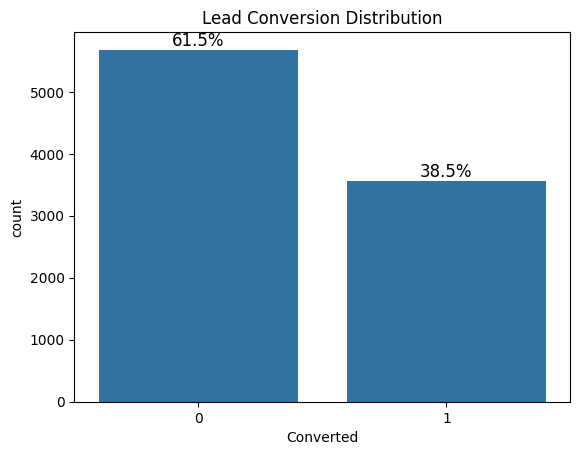

In [14]:
import matplotlib.pyplot as plt
ax = sns.countplot(x='Converted', data=data_frame)

plt.title("Lead Conversion Distribution")

# Total rows
total = len(data_frame)

# Add percentage labels
for p in ax.patches:
    count = p.get_height()
    percentage = 100 * count / total
    
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width() / 2., count),
                ha='center',
                va='bottom',
                fontsize=12)

plt.show()

In [15]:
conversion_rate = data_frame['Converted'].mean() * 100

print(f"Conversion Rate: {conversion_rate:.2f}%")

Conversion Rate: 38.54%


> **The boxplot shows that users who converted generally spent significantly more time on the website compared to users who did not convert. The median website time for converted leads is much higher, indicating that user engagement plays an important role in lead conversion. Some non-converted users also spent high time on the website, which appear as outliers and may indicate interested users who dropped off before final conversion.**

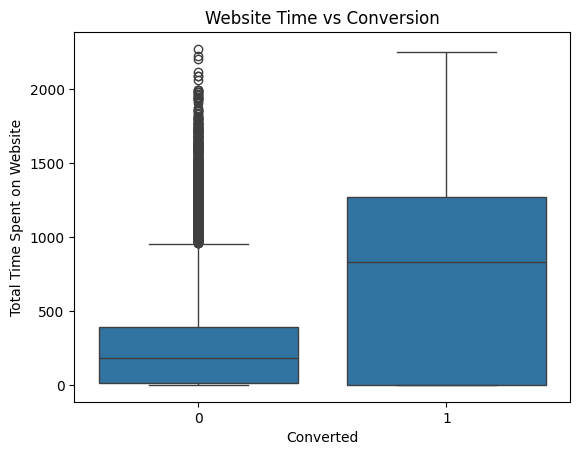

In [16]:
sns.boxplot(x='Converted', y='Total Time Spent on Website', data=data_frame)

plt.title("Website Time vs Conversion")

plt.show()

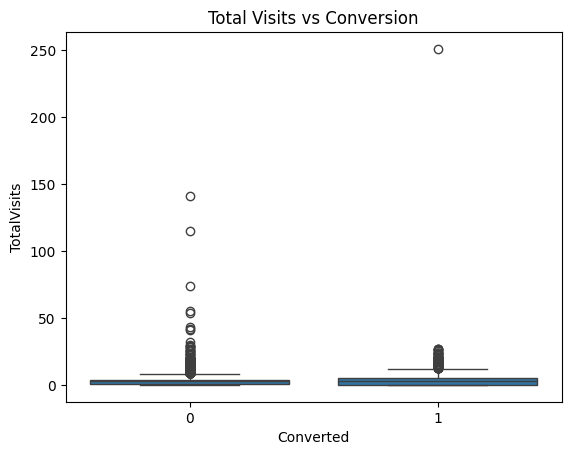

In [17]:
sns.boxplot(x='Converted', y='TotalVisits', data=data_frame)

plt.title("Total Visits vs Conversion")

plt.show()

# Categorical Feature Analysis

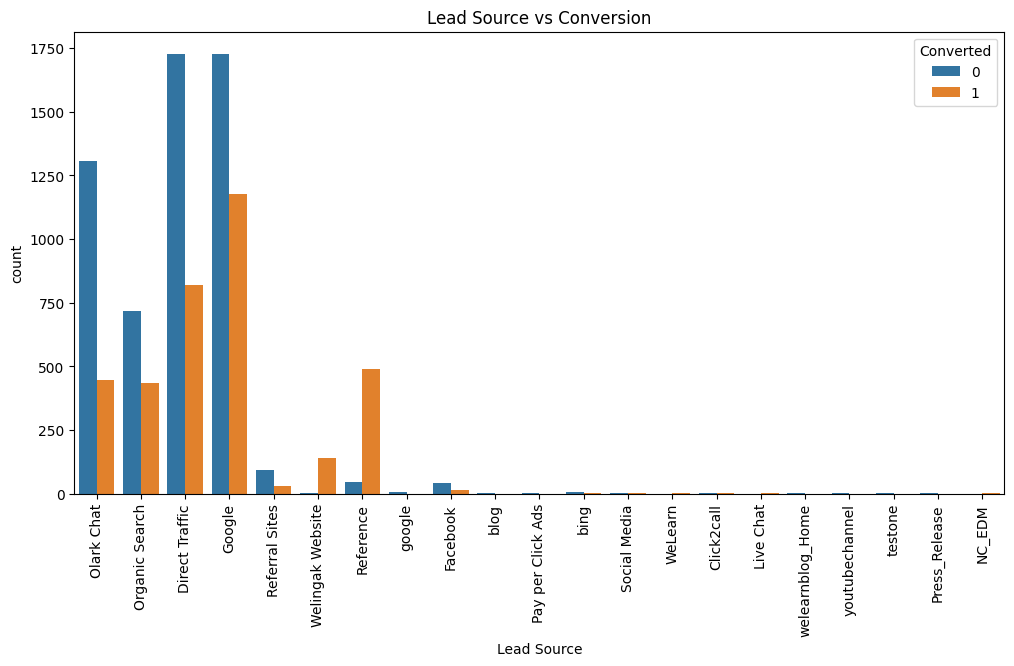

In [18]:
plt.figure(figsize=(12,6))

sns.countplot(x='Lead Source', hue='Converted', data=data_frame)

plt.xticks(rotation=90)

plt.title("Lead Source vs Conversion")

plt.show()

> **The countplot indicates that Google and Direct Traffic are the major sources of lead generation. However, Google shows a comparatively stronger conversion performance. Reference-based leads also demonstrate a high conversion tendency despite lower traffic volume, indicating better lead quality. Olark Chat contributes significantly to conversions, suggesting that live customer interaction positively impacts lead conversion. Some channels such as blogs and social media contribute relatively fewer conversions.**

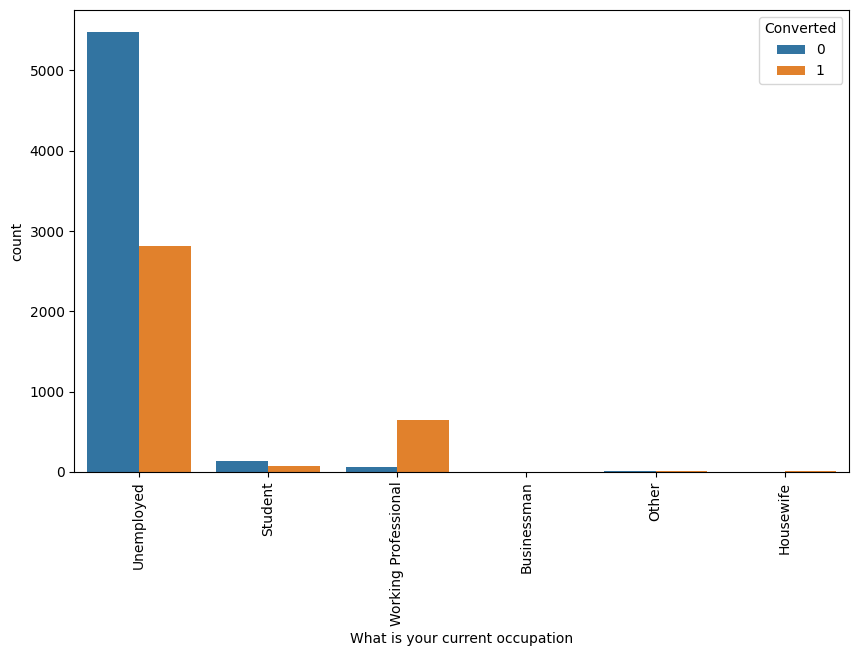

In [19]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='What is your current occupation',
    hue='Converted',
    data=data_frame
)

plt.xticks(rotation=90)

plt.show()

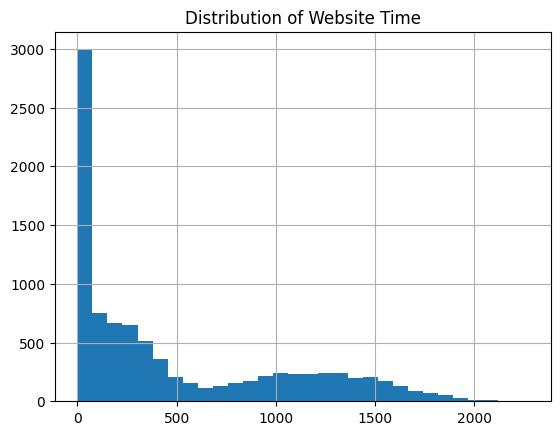

In [20]:
data_frame['Total Time Spent on Website'].hist(bins=30)

plt.title("Distribution of Website Time")

plt.show()

<Axes: >

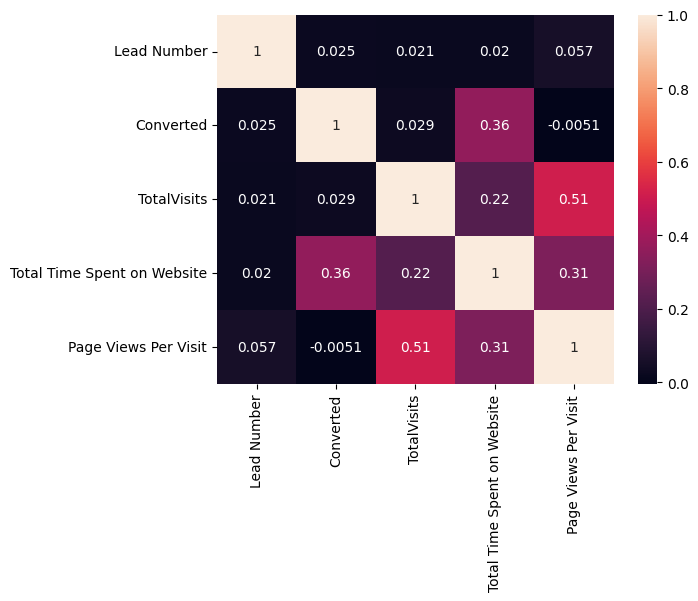

In [21]:
correlation = data_frame.select_dtypes( 
   include=['number'] 
).corr() 
 
sns.heatmap(correlation, annot=True) 

In [22]:
data_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 19 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Full Name                                      9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9240 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Converted                                      9240 non-null   int64  
 6   TotalVisits                                    9240 non-null   float64
 7   Total Time Spent on Website                    9240 non-null   int64  
 8   Page Views Per Visit                           9240 non-null   float64
 9   Last Activity                                  9240 

In [23]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Example: Label Encoding for Lead Origin
le = LabelEncoder()
data_frame['Lead Origin'] = le.fit_transform(data_frame['Lead Origin'])

# Example: One-Hot Encoding for Lead Source
data_frame = pd.get_dummies(data_frame, columns=['Lead Source'], drop_first=True)

In [24]:
# Example: One-Hot Encoding for Last Activity
data_frame = pd.get_dummies(data_frame, columns=['Last Activity'], drop_first=True)

# Example: Label Encoding for Occupation (if categories are few)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data_frame['Occupation_encoded'] = le.fit_transform(data_frame['What is your current occupation'].astype(str))

In [25]:
data_frame.head()

,Full Name,Lead Number,Lead Origin,Do Not Email,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Country,Specialization,...,Last Activity_Had a Phone Conversation,Last Activity_Olark Chat Conversation,Last Activity_Page Visited on Website,Last Activity_Resubscribed to emails,Last Activity_SMS Sent,Last Activity_Unreachable,Last Activity_Unsubscribed,Last Activity_View in browser link Clicked,Last Activity_Visited Booth in Tradeshow,Occupation_encoded
0,Brandon Allen,660737,0,No,0,0.0,0,0.0,India,Select,...,False,False,True,False,False,False,False,False,False,4
1,Kenneth Baker,660728,0,No,0,5.0,674,2.5,India,Select,...,False,False,False,False,False,False,False,False,False,4
2,Steven Torres,660727,1,No,1,2.0,1532,2.0,India,Business Administration,...,False,False,False,False,False,False,False,False,False,3
3,Ethan Ruiz,660719,1,No,0,1.0,305,1.0,India,Media and Advertising,...,False,False,False,False,False,True,False,False,False,4
4,Brandon Morris,660681,1,No,1,2.0,1428,1.0,India,Select,...,False,False,False,False,False,False,False,False,False,4


In [26]:
from sklearn.model_selection import train_test_split

X = data_frame.drop(columns=['Converted'])  # features
y = data_frame['Converted']                 # target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Separate features and target
X = data_frame.drop(columns=['Converted'])
y = data_frame['Converted']

# Identify categorical and numeric columns
categorical_cols = X.select_dtypes(include=['object']).columns
numeric_cols = X.select_dtypes(include=['int64', 'float64', 'bool']).columns

# Fill missing values

# Numerical columns → Median
for col in numeric_cols:
    X[col] = X[col].fillna(X[col].median())

# Categorical columns → Unknown
for col in categorical_cols:
    X[col] = X[col].fillna('Unknown')

# Verify no missing values remain
print("Remaining Missing Values:")
print(X.isnull().sum().sum())

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Logistic Regression
log_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler(with_mean=False)),
    ('model', LogisticRegression(max_iter=5000, solver='saga'))
])

log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

# Random Forest
rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("\nRandom Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Remaining Missing Values:
0
Logistic Regression Accuracy: 0.8198051948051948

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.94      0.86      1107
           1       0.88      0.64      0.74       741

    accuracy                           0.82      1848
   macro avg       0.84      0.79      0.80      1848
weighted avg       0.83      0.82      0.81      1848


Random Forest Accuracy: 0.849025974025974

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.94      0.86      1107
           1       0.88      0.64      0.74       741

    accuracy                           0.82      1848
   macro avg       0.84      0.79      0.80      1848
weighted avg       0.83      0.82      0.81      1848



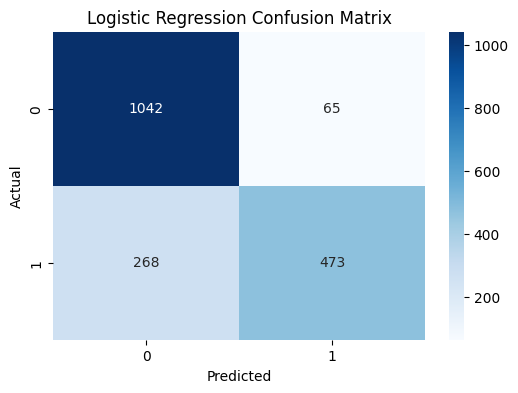

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))
sns.heatmap(cm_lr,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

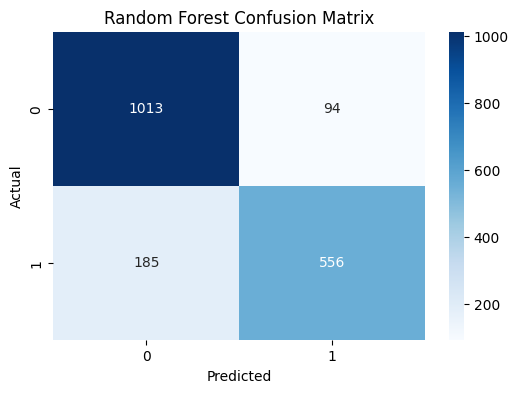

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

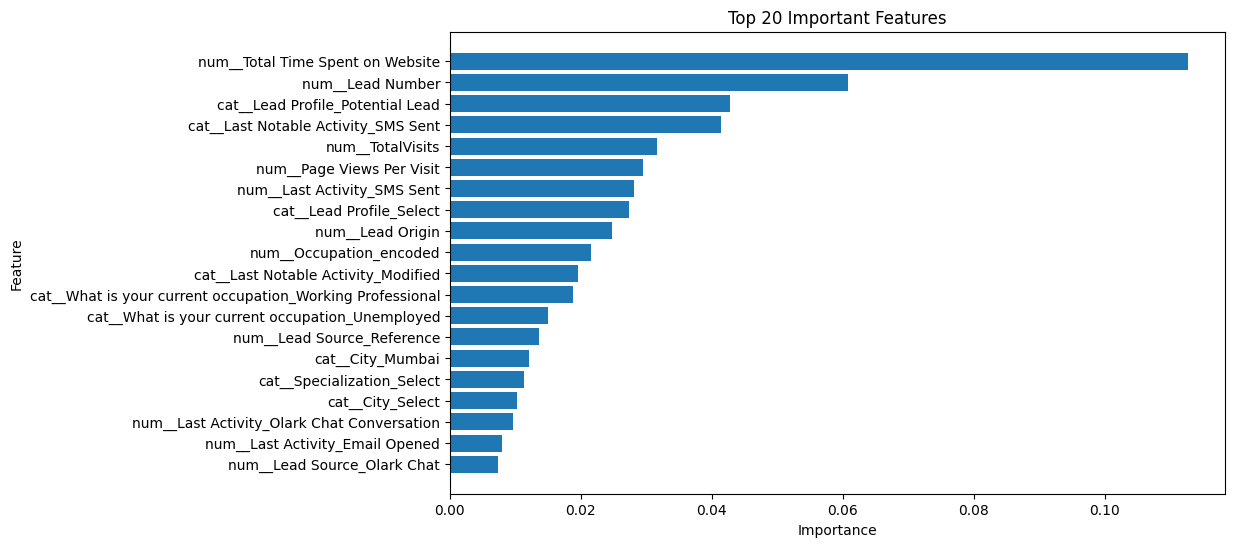

In [30]:
# Feature names
feature_names = rf.named_steps['preprocessor'].get_feature_names_out()

# Importance values
importances = rf.named_steps['model'].feature_importances_

# Create dataframe
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort values
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

# Top 10 features
top20 = importance_df.head(20)

# Plot
plt.figure(figsize=(10,6))

plt.barh(top20['Feature'], top20['Importance'])

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Important Features")

plt.gca().invert_yaxis()

plt.show()

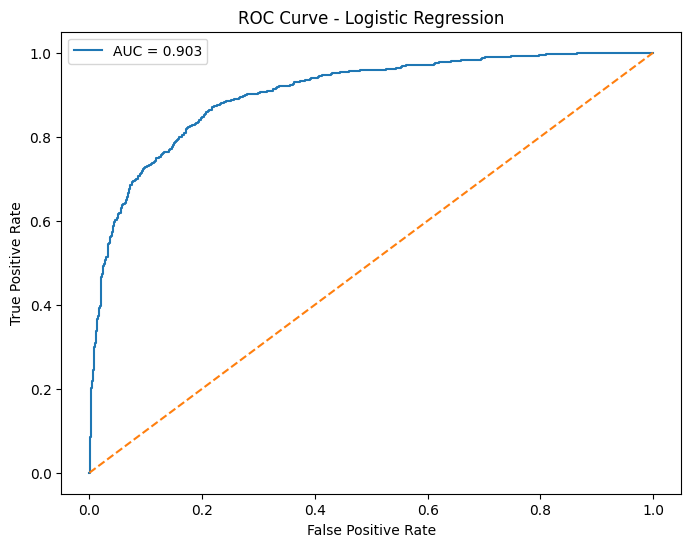

AUC Score: 0.9031217122787514


In [31]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probability predictions
y_prob_lr = log_reg.predict_proba(X_test)[:,1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)

# AUC Score
auc_score = roc_auc_score(y_test, y_prob_lr)

# Plot ROC Curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.3f}')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

print("AUC Score:", auc_score)

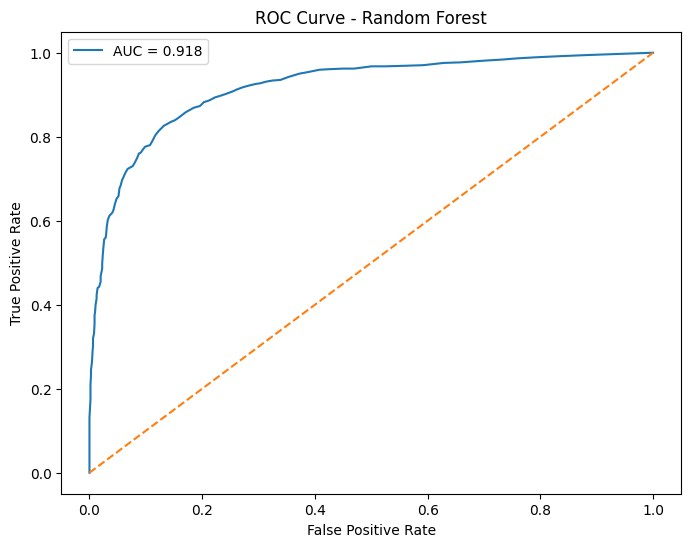

AUC Score: 0.9178549702725997


In [32]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probability predictions
y_prob_rf = rf.predict_proba(X_test)[:,1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

# AUC Score
auc_score = roc_auc_score(y_test, y_prob_rf)

# Plot ROC Curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.3f}')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

print("AUC Score:", auc_score)